# ECO225: Data Tools for Economists  
## Statistical Inference + Regression  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Part A: Statistical Inference

We begin with the core ideas from Week 7:
- confidence intervals
- one-sample tests
- comparing two groups
- paired tests for before/after analysis


### A1. Confidence Interval Example

Suppose we observe sample GDP growth rates and want to estimate the average growth rate in the population.


In [2]:
gdp_growth = np.array([2.1, 2.5, 1.8, 3.2, 2.7, 2.3, 2.9, 2.4, 2.6, 2.2])

mean = np.mean(gdp_growth)
std_error = stats.sem(gdp_growth)
ci = stats.t.interval(0.95, df=len(gdp_growth)-1, loc=mean, scale=std_error)

print(f"Sample mean: {mean:.2f}%")
print(f"95% confidence interval: [{ci[0]:.2f}, {ci[1]:.2f}]")

Sample mean: 2.47%
95% confidence interval: [2.18, 2.76]


### A2. One-Sample t-test Example

Now test whether the average GDP growth rate differs from **2.0%**.
- Null hypothesis: \(H_0: \mu = 2.0\)
- Alternative hypothesis: \(H_1: \mu \neq 2.0\)


In [3]:
hypothesized_mean = 2.0
t_stat, p_value = stats.ttest_1samp(gdp_growth, hypothesized_mean)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 3.6639
p-value: 0.0052


### A3. Two-Sample t-test Example

Compare unemployment rates across two regions.


In [4]:
region_a = np.array([5.2, 5.8, 5.5, 6.1, 5.9, 5.7])
region_b = np.array([4.1, 4.5, 4.3, 4.8, 4.6, 4.2])

t_stat, p_value = stats.ttest_ind(region_a, region_b)

print(f"Mean of Region A: {np.mean(region_a):.2f}")
print(f"Mean of Region B: {np.mean(region_b):.2f}")
print(f"p-value: {p_value:.4f}")

Mean of Region A: 5.70
Mean of Region B: 4.42
p-value: 0.0000


### A4. Paired t-test Example

A paired test is appropriate when we compare the **same units before and after** a policy intervention.


In [5]:
before = np.array([6.5, 7.1, 6.8, 7.3, 6.9, 7.0])
after = np.array([6.0, 6.7, 6.3, 6.8, 6.4, 6.5])

t_stat, p_value = stats.ttest_rel(before, after)
avg_change = np.mean(after - before)

print(f"Average change (after - before): {avg_change:.2f}")
print(f"p-value: {p_value:.4f}")

Average change (after - before): -0.48
p-value: 0.0000


## Part B: Regression Analysis

Now we move to Week 8 material and model relationships directly.


### B1. Simple Linear Regression Example

We study the relationship between years of education and income.


In [6]:
education_years = np.array([12, 13, 14, 16, 18, 20, 22])
income = np.array([35, 38, 42, 52, 65, 78, 92])

slope, intercept, r_value, p_value, std_err = stats.linregress(education_years, income)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")

Slope: 5.78
Intercept: -37.50
R-squared: 0.9898
p-value: 0.0000


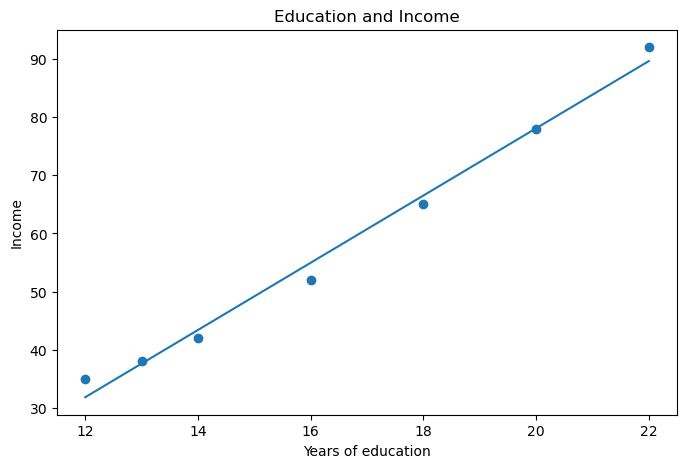

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(education_years, income)
plt.plot(education_years, intercept + slope * education_years)
plt.xlabel("Years of education")
plt.ylabel("Income")
plt.title("Education and Income")
plt.show()

### B2. Regression with `statsmodels`

This gives a more complete regression table.


In [8]:
X = sm.add_constant(education_years)
model = sm.OLS(income, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     486.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.56e-06
Time:                        03:11:57   Log-Likelihood:                -14.876
No. Observations:                   7   AIC:                             33.75
Df Residuals:                       5   BIC:                             33.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.4983      4.399     -8.524      0.0

/opt/conda/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### B3. Multiple Regression Example

We predict income using education, experience, and age.


In [9]:
np.random.seed(42)
n = 50

df = pd.DataFrame({
    'education': np.random.randint(10, 21, n),
    'experience': np.random.randint(0, 31, n),
    'age': np.random.randint(22, 60, n)
})

df['income'] = (
    5 + 3.2*df['education'] + 1.1*df['experience'] - 0.2*df['age']
    + np.random.normal(0, 5, n)
)

X = sm.add_constant(df[['education', 'experience', 'age']])
y = df['income']

multi_model = sm.OLS(y, X).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     133.4
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.06e-22
Time:                        03:11:58   Log-Likelihood:                -143.41
No. Observations:                  50   AIC:                             294.8
Df Residuals:                      46   BIC:                             302.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0983      3.872      1.575      0.1

---

## Graded Tasks

These tasks combine both labs into one shorter assessed practical.  
Total: **100 points**


### Task 1: Confidence Interval (20 points)

Calculate the **95% confidence interval** for the mean inflation rate.

Report:
1. the sample mean
2. the lower bound
3. the upper bound


In [11]:
inflation_rates = np.array([2.3, 2.8, 2.1, 3.5, 2.9, 2.5, 3.1, 2.7, 2.4, 2.6])

# TODO: Calculate the sample mean
# TODO: Calculate the standard error
# TODO: Calculate the 95% confidence interval

# Your code below

smean = np.mean(inflation_rates)
std_error = stats.sem(inflation_rates)
ci = stats.t.interval(0.95, df=len(inflation_rates)-1, loc=mean, scale=std_error)

print(f"Sample mean: {mean:.2f}%")
print(f"Standard Error: {std_error:.2f}%")
print(f"95% confidence interval: [{ci[0]:.2f}, {ci[1]:.2f}]")



Sample mean: 2.47%
Standard Error: 0.13%
95% confidence interval: [2.18, 2.76]


### Task 2: One-Sample Hypothesis Test (20 points)

Test whether average wage growth differs from **3.0%**.

Report:
1. the t-statistic
2. the p-value
3. a one-sentence conclusion at the 5% significance level


In [12]:
wage_growth = np.array([3.2, 2.8, 3.5, 3.1, 2.9, 3.4, 3.0, 3.3, 2.7, 3.6])

# TODO: Perform a one-sample t-test against 3.0

# Your code below
t_stat, p_value = stats.ttest_1samp(wage_growth, 3.0)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.5f}")

#since p value is greater than 0.05, not statistically significant
# fail to reject null


t-statistic: 1.57
p-value: 0.15163


### Task 3: Policy Evaluation with Paired Data (20 points)

A minimum wage policy was introduced. Test whether employment changed.

Report:
1. the average change in employment
2. the t-statistic
3. the p-value
4. a brief interpretation


In [13]:
employment_before = np.array([85.2, 84.8, 85.5, 84.9, 85.1, 84.7, 85.3, 85.0])
employment_after = np.array([84.5, 84.1, 84.8, 84.3, 84.6, 84.0, 84.7, 84.4])

# TODO: Perform a paired t-test
# TODO: Calculate the average change
# TODO: Interpret the result

# Your code below

change = employment_after - employment_before
avg_change = np.mean(change)
t_stat, p_value = stats.ttest_rel(employment_after, employment_before)

print(f"Average change in employment: {avg_change:.2f}")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.5f}")

#We reject the null hypothesis at the 5% level, its statistically signifcant
# with employment significantly changing after the policy.

Average change in employment: -0.64
t-statistic: -24.23
p-value: 0.00000


### Task 4: Simple Regression (20 points)

Analyze the relationship between advertising spending and sales.

Report:
1. the slope coefficient
2. the intercept
3. the R-squared value
4. a scatter plot with regression line
5. one sentence interpreting the slope


Slope: 2.64
Intercept: 23.93
R-squared: 0.9978


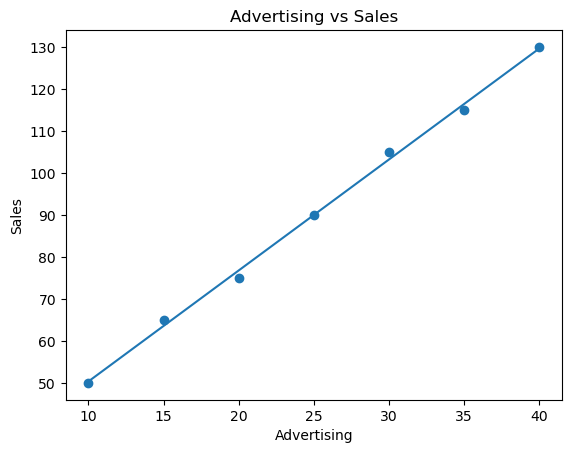

In [14]:
advertising = np.array([10, 15, 20, 25, 30, 35, 40])
sales = np.array([50, 65, 75, 90, 105, 115, 130])

# TODO: Run the simple regression
# TODO: Plot the data and regression line
# TODO: Interpret the slope

# Your code below
slope, intercept, r_value, p_value, std_err = stats.linregress(advertising, sales)

# R-squared
r_squared = r_value**2

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_squared:.4f}")

# Plot
plt.scatter(advertising, sales)
plt.plot(advertising, intercept + slope * advertising)
plt.xlabel("Advertising")
plt.ylabel("Sales")
plt.title("Advertising vs Sales")
plt.show()

#For each additional unit of advertising, sales increase by
# approximately 2.64 units

### Task 5: Multiple Regression and Prediction (20 points)

Use house characteristics to predict price.

Steps:
1. estimate a regression of `price` on `size`, `bedrooms`, and `age`
2. report the coefficients
3. predict the price of a house with:
   - 2000 sq ft
   - 3 bedrooms
   - 10 years old
4. compare this full model to a smaller model using only `size` and `bedrooms`
5. state which model is better using **R²** and **adjusted R²**


In [16]:
np.random.seed(123)
n = 40

house_df = pd.DataFrame({
    'size': np.random.uniform(800, 3000, n),
    'bedrooms': np.random.randint(1, 6, n),
    'age': np.random.randint(0, 50, n)
})

house_df['price'] = (
    0.15 * house_df['size'] +
    15 * house_df['bedrooms'] -
    2 * house_df['age'] +
    np.random.normal(0, 20, n) + 10
)

house_df.head()

,size,bedrooms,age,price
0,2332.232208,4,38,354.066033
1,1429.506537,3,17,264.254790
2,1299.073198,1,46,111.122825
3,2012.892492,5,10,376.131314
4,2382.831734,4,35,328.890753


In [19]:
# TODO: Estimate full model with size, bedrooms, and age
# TODO: Estimate smaller model with only size and bedrooms
# TODO: Predict the price for a 2000 sq ft, 3 bedroom, 10 year old house
# TODO: Compare R-squared and adjusted R-squared
# TODO: State which model is better

# Your code below

X_full = house_df[['size', 'bedrooms', 'age']]
X_full = sm.add_constant(X_full)
y = house_df['price']
model_full = sm.OLS(y, X_full).fit()
print("Full model coefficients:")
print(model_full.params)

X_small = house_df[['size', 'bedrooms']]
X_small = sm.add_constant(X_small)
model_small = sm.OLS(y, X_small).fit()

new_house = pd.DataFrame({'const': [1],'size': [2000],'bedrooms': [3],
                          'age': [10]})

predicted_price = model_full.predict(new_house)[0]
print(f"\nPredicted price: {predicted_price:.2f}")

print("\nModel comparison:")
print(f"Full model R²: {model_full.rsquared:.2f}")
print(f"Full model Adjusted R²: {model_full.rsquared_adj:.2f}")
print(f"Small model R²: {model_small.rsquared:.2f}")
print(f"Small model Adjusted R²: {model_small.rsquared_adj:.2f}")

# The full model is better based on higher R² and adjusted R².")


Full model coefficients:
const       19.984761
size         0.149219
bedrooms    15.062583
age         -2.410559
dtype: float64

Predicted price: 339.50

Model comparison:
Full model R²: 0.96
Full model Adjusted R²: 0.96
Small model R²: 0.78
Small model Adjusted R²: 0.77


## Submission Reminder

For a graded submission, make sure your notebook includes:
- working code
- outputs shown
- short written interpretations where requested

## End of Combined Lab
